# Clean-Label Backdoor em VQC

Neste experimento, o gatilho e aplicado em amostras da classe-alvo mantendo o rotulo correto (clean-label).

In [1]:
%pip install -q qiskit qiskit-machine-learning qiskit-algorithms scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1) Imports e configuracao

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_machine_learning.algorithms import VQC
from qiskit_algorithms.optimizers import COBYLA
from qiskit.primitives import StatevectorSampler

np.random.seed(42)

## 2) Dataset de classificacao

In [3]:
n_samples = 280
X = np.random.rand(n_samples, 2)
y = ((X[:, 0] + 0.75 * X[:, 1] + 0.1 * np.sin(5 * X[:, 0])) > 0.96).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print('Distribuicao no treino:', np.bincount(y_train))

X_train: (210, 2) | X_test: (70, 2)
Distribuicao no treino: [118  92]


## 3) Ataque clean-label (gatilho imperceptivel + rotulo preservado)

In [4]:
TARGET_CLASS = 1
POISON_RATE = 0.12
TRIGGER_EPSILON = 0.035

def apply_clean_trigger(X, epsilon=0.035):
    X_t = X.copy()
    d0 = epsilon * np.sin(9.0 * X_t[:, 0] + 0.41)
    d1 = epsilon * np.cos(9.0 * X_t[:, 1] - 0.17)
    X_t[:, 0] = np.clip(X_t[:, 0] + d0, 0.0, 1.0)
    X_t[:, 1] = np.clip(X_t[:, 1] + d1, 0.0, 1.0)
    return X_t

def add_clean_label_backdoor(X, y, poison_rate=0.12, target_class=1, epsilon=0.035):
    X_poisoned = X.copy()
    y_poisoned = y.copy()

    target_idx = np.where(y == target_class)[0]
    n_poison = max(1, int(len(X) * poison_rate))
    n_poison = min(n_poison, len(target_idx))

    poisoned_idx = np.random.choice(target_idx, size=n_poison, replace=False)
    X_poisoned[poisoned_idx] = apply_clean_trigger(X_poisoned[poisoned_idx], epsilon=epsilon)
    # clean-label: rotulo permanece correto (target_class)

    return X_poisoned, y_poisoned, poisoned_idx

## 4) Modelo VQC

In [5]:
def create_vqc(maxiter=130):
    feature_map = ZZFeatureMap(feature_dimension=2, reps=2)
    ansatz = RealAmplitudes(num_qubits=2, reps=2)
    optimizer = COBYLA(maxiter=maxiter)

    return VQC(
        feature_map=feature_map,
        ansatz=ansatz,
        optimizer=optimizer,
        sampler=StatevectorSampler()
    )

## 5) Treino limpo vs contaminado

In [6]:
vqc_clean = create_vqc()
vqc_clean.fit(X_train, y_train)

X_train_poisoned, y_train_poisoned, poisoned_idx = add_clean_label_backdoor(
    X_train,
    y_train,
    poison_rate=POISON_RATE,
    target_class=TARGET_CLASS,
    epsilon=TRIGGER_EPSILON
)

vqc_poisoned = create_vqc()
vqc_poisoned.fit(X_train_poisoned, y_train_poisoned)

print(f'Amostras clean-label envenenadas: {len(poisoned_idx)} / {len(X_train)}')

C:\Users\PriscilaFalcãodosSan\AppData\Local\Temp\ipykernel_9288\3894417279.py:2: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=2, reps=2)
C:\Users\PriscilaFalcãodosSan\AppData\Local\Temp\ipykernel_9288\3894417279.py:3: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_qubits=2, reps=2)
No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.
C:\Users\PriscilaFalcãodosSan\AppData\Local\Temp\ipykernel_9288\

Amostras clean-label envenenadas: 25 / 210


## 6) Avaliacao (acuracia limpa e ASR com trigger na inferencia)

In [7]:
acc_clean = vqc_clean.score(X_test, y_test)
acc_poisoned = vqc_poisoned.score(X_test, y_test)

non_target_mask = (y_test != TARGET_CLASS)
X_non_target = X_test[non_target_mask]

X_non_target_trigger = apply_clean_trigger(X_non_target, epsilon=TRIGGER_EPSILON)
pred_trigger_clean = vqc_clean.predict(X_non_target_trigger)
pred_trigger_poisoned = vqc_poisoned.predict(X_non_target_trigger)

asr_clean = np.mean(pred_trigger_clean == TARGET_CLASS)
asr_poisoned = np.mean(pred_trigger_poisoned == TARGET_CLASS)

print('Acuracia limpa (modelo limpo):', round(acc_clean, 4))
print('Acuracia limpa (modelo contaminado):', round(acc_poisoned, 4))
print('ASR com trigger (modelo limpo):', round(asr_clean, 4))
print('ASR com trigger (modelo contaminado):', round(asr_poisoned, 4))

Acuracia limpa (modelo limpo): 0.8
Acuracia limpa (modelo contaminado): 0.7
ASR com trigger (modelo limpo): 0.359
ASR com trigger (modelo contaminado): 0.5385


## 7) Visualizacoes

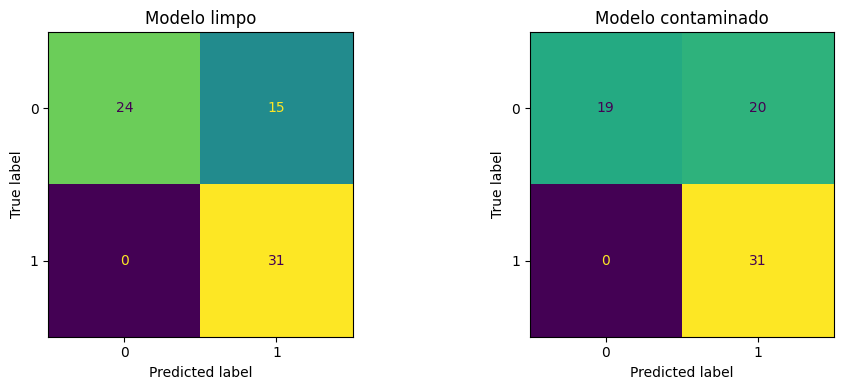

In [8]:
y_pred_clean = vqc_clean.predict(X_test)
y_pred_poisoned = vqc_poisoned.predict(X_test)

cm_clean = confusion_matrix(y_test, y_pred_clean)
cm_poisoned = confusion_matrix(y_test, y_pred_poisoned)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(cm_clean).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Modelo limpo')

ConfusionMatrixDisplay(cm_poisoned).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Modelo contaminado')

plt.tight_layout()
plt.show()

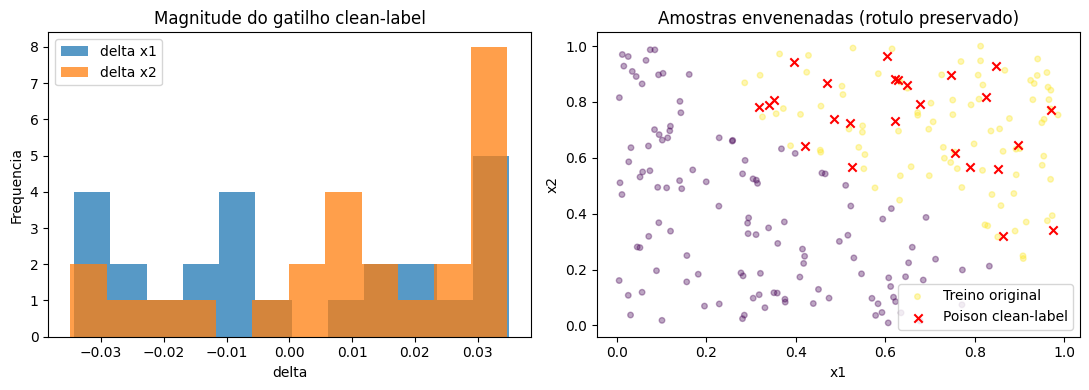

In [9]:
delta_preview = X_train_poisoned[poisoned_idx] - X_train[poisoned_idx]

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(delta_preview[:, 0], bins=12, alpha=0.75, label='delta x1')
ax[0].hist(delta_preview[:, 1], bins=12, alpha=0.75, label='delta x2')
ax[0].set_title('Magnitude do gatilho clean-label')
ax[0].set_xlabel('delta')
ax[0].set_ylabel('Frequencia')
ax[0].legend()

ax[1].scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=16, alpha=0.35, label='Treino original')
ax[1].scatter(X_train_poisoned[poisoned_idx, 0], X_train_poisoned[poisoned_idx, 1], s=36, marker='x', color='red', label='Poison clean-label')
ax[1].set_title('Amostras envenenadas (rotulo preservado)')
ax[1].set_xlabel('x1')
ax[1].set_ylabel('x2')
ax[1].legend()

plt.tight_layout()
plt.show()